#Modelo

In [ ]:
import numpy as np
import pandas as pd
import random
import sqlite3

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, matthews_corrcoef

from collections import defaultdict, deque

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
#BLOQUE 1 - CARGA
DB_PATH = "/content/database.sqlite"

conn = sqlite3.connect(DB_PATH)


In [ ]:
#BLOQUE A - PLAYER ATTRIBUTES

player_attr = pd.read_sql("""
SELECT
    player_api_id,
    date,
    overall_rating,
    attacking_work_rate,
    defensive_work_rate
FROM Player_Attributes
WHERE overall_rating IS NOT NULL
""", conn)

player_attr["date"] = pd.to_datetime(player_attr["date"])
player_attr = player_attr.sort_values("date")

print(player_attr.shape)
player_attr.head()


(183142, 5)


,player_api_id,date,overall_rating,attacking_work_rate,defensive_work_rate
183141,39902,2007-02-22,80,medium,low
147007,79775,2007-02-22,70,medium,medium
61081,41071,2007-02-22,72,medium,high
11398,172187,2007-02-22,65,medium,medium
147017,19512,2007-02-22,69,medium,medium


In [ ]:
#BLOQUE B - TEAM ATTRIBUTES EXTENDIDO (FIFA)


team_attr = pd.read_sql("""
SELECT
    team_api_id,
    date,

    -- Build-up play
    buildUpPlaySpeed,
    buildUpPlayDribbling,
    buildUpPlayPassing,

    -- Chance creation
    chanceCreationPassing,
    chanceCreationCrossing,
    chanceCreationShooting,

    -- Defence
    defencePressure,
    defenceAggression,
    defenceTeamWidth

FROM Team_Attributes
WHERE
    buildUpPlaySpeed IS NOT NULL
    AND buildUpPlayPassing IS NOT NULL
    AND chanceCreationPassing IS NOT NULL
    AND defencePressure IS NOT NULL
""", conn)

# Parse fecha
team_attr["date"] = pd.to_datetime(team_attr["date"])
team_attr = team_attr.sort_values("date")

# ---------- AGREGADOS TIPO PAPER ----------

#taque
team_attr["attack_rating"] = (
    team_attr["buildUpPlaySpeed"] +
    team_attr["buildUpPlayPassing"] +
    team_attr["chanceCreationPassing"] +
    team_attr["chanceCreationCrossing"] +
    team_attr["chanceCreationShooting"]
) / 5

#Defensa
team_attr["defence_rating"] = (
    team_attr["defencePressure"] +
    team_attr["defenceAggression"] +
    team_attr["defenceTeamWidth"]
) / 3

#rating global del equipo
team_attr["team_fifa_rating"] = (
    team_attr["attack_rating"] +
    team_attr["defence_rating"]
) / 2

print("Team attributes shape:", team_attr.shape)
team_attr.head()


Team attributes shape: (1458, 14)


,team_api_id,date,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth,attack_rating,defence_rating,team_fifa_rating
0,9930,2010-02-22,60,NaN,50,60,65,55,50,55,45,58.0,50.000000,54.000000
426,8674,2010-02-22,41,NaN,32,40,47,69,30,30,30,45.8,30.000000,37.900000
1147,10189,2010-02-22,65,NaN,55,55,70,70,70,45,70,63.0,61.666667,62.333333
419,8722,2010-02-22,55,NaN,65,65,40,60,45,55,70,57.0,56.666667,56.833333
418,8596,2010-02-22,70,NaN,70,60,70,70,60,70,70,68.0,66.666667,67.333333


In [ ]:
#BLOQUE C - TEAM FIFA RATINGS POR PARTIDO (SIN LEAKAGE)


#inicializar columnas
matches["home_fifa_rating"] = np.nan
matches["away_fifa_rating"] = np.nan

#asignar rating más reciente previo al partido
for idx, row in matches.iterrows():
    match_date = row.date

    # HOME TEAM
    home_attr = team_attr[
        (team_attr.team_api_id == row.home_team_api_id) &
        (team_attr.date < match_date)
    ]

    if len(home_attr) > 0:
        matches.at[idx, "home_fifa_rating"] = home_attr.iloc[-1]["team_fifa_rating"]

    # AWAY TEAM
    away_attr = team_attr[
        (team_attr.team_api_id == row.away_team_api_id) &
        (team_attr.date < match_date)
    ]

    if len(away_attr) > 0:
        matches.at[idx, "away_fifa_rating"] = away_attr.iloc[-1]["team_fifa_rating"]



matches["fifa_rating_diff"] = (
    matches["home_fifa_rating"] - matches["away_fifa_rating"]
)



In [ ]:
# BLOQUE 2 - PARTIDOS


matches = pd.read_sql("""
SELECT
    id,
    date,
    season,
    league_id,
    home_team_api_id,
    away_team_api_id,
    home_team_goal,
    away_team_goal
FROM Match
WHERE home_team_goal IS NOT NULL
""", conn)

matches["date"] = pd.to_datetime(matches["date"])
matches = matches.sort_values("date").reset_index(drop=True)

print(matches.shape)
matches.head()


(25979, 8)


,id,date,season,league_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,24559,2008-07-18,2008/2009,24558,10192,9931,1,2
1,24560,2008-07-19,2008/2009,24558,9930,10179,3,1
2,24561,2008-07-20,2008/2009,24558,10199,9824,1,2
3,24562,2008-07-20,2008/2009,24558,7955,10243,1,2
4,24614,2008-07-23,2008/2009,24558,6493,7955,1,2


In [ ]:
#bLOQUE 3 - TARGET
# Se seleccionan atributos de jugadores como la calificación general y
#el ritmo de trabajo, y se procesan las fechas para ordenarlos cronológicamente.


def build_target(row):
    if row.home_team_goal > row.away_team_goal:
        return 0  # Home Win
    elif row.home_team_goal == row.away_team_goal:
        return 1  # Draw
    else:
        return 2  # Home Lose

matches["target"] = matches.apply(build_target, axis=1)
matches["target"].value_counts(normalize=True)


,proportion
target,
0,0.458717
2,0.287386
1,0.253897


In [ ]:
# BLOQUE 4 - ROLLING TEAM FEATURES (EXTENDIDO, SIN LEAKAGE)
#Se cargan atributos de equipo relacionados con la construcción de juego, creación de oportunidades y defensa.
#A partir de estos, se calculan calificaciones agregadas de ataque, defensa y una calificación FIFA general del equipo.

from collections import defaultdict, deque

WINDOWS = [5, 10, 15]

# Estructuras por ventana
team_goals_for = {w: defaultdict(lambda: deque(maxlen=w)) for w in WINDOWS}
team_goals_against = {w: defaultdict(lambda: deque(maxlen=w)) for w in WINDOWS}
team_results = {w: defaultdict(lambda: deque(maxlen=w)) for w in WINDOWS}  # W=3, D=1, L=0

# Inicializar columnas
for w in WINDOWS:
    for side in ["home", "away"]:
        matches[f"{side}_avg_goals_last{w}"] = np.nan
        matches[f"{side}_avg_conceded_last{w}"] = np.nan
        matches[f"{side}_goal_diff_last{w}"] = np.nan
        matches[f"{side}_winrate_last{w}"] = np.nan
        matches[f"{side}_drawrate_last{w}"] = np.nan
        matches[f"{side}_form_last{w}"] = np.nan

# Iterar cronológicamente
for idx, row in matches.iterrows():
    home = row.home_team_api_id
    away = row.away_team_api_id

    for w in WINDOWS:
        # HOME
        if len(team_goals_for[w][home]) > 0:
            gf = np.mean(team_goals_for[w][home])
            ga = np.mean(team_goals_against[w][home])
            res = list(team_results[w][home])

            matches.at[idx, f"home_avg_goals_last{w}"] = gf
            matches.at[idx, f"home_avg_conceded_last{w}"] = ga
            matches.at[idx, f"home_goal_diff_last{w}"] = gf - ga
            matches.at[idx, f"home_winrate_last{w}"] = sum(r == 3 for r in res) / len(res)
            matches.at[idx, f"home_drawrate_last{w}"] = sum(r == 1 for r in res) / len(res)
            matches.at[idx, f"home_form_last{w}"] = np.mean(res)

        # AWAY
        if len(team_goals_for[w][away]) > 0:
            gf = np.mean(team_goals_for[w][away])
            ga = np.mean(team_goals_against[w][away])
            res = list(team_results[w][away])

            matches.at[idx, f"away_avg_goals_last{w}"] = gf
            matches.at[idx, f"away_avg_conceded_last{w}"] = ga
            matches.at[idx, f"away_goal_diff_last{w}"] = gf - ga
            matches.at[idx, f"away_winrate_last{w}"] = sum(r == 3 for r in res) / len(res)
            matches.at[idx, f"away_drawrate_last{w}"] = sum(r == 1 for r in res) / len(res)
            matches.at[idx, f"away_form_last{w}"] = np.mean(res)

    # Actualizar históricos (DESPUÉS del partido)
    for w in WINDOWS:
        # Home
        team_goals_for[w][home].append(row.home_team_goal)
        team_goals_against[w][home].append(row.away_team_goal)

        if row.home_team_goal > row.away_team_goal:
            team_results[w][home].append(3)
        elif row.home_team_goal == row.away_team_goal:
            team_results[w][home].append(1)
        else:
            team_results[w][home].append(0)

        # Away
        team_goals_for[w][away].append(row.away_team_goal)
        team_goals_against[w][away].append(row.home_team_goal)

        if row.away_team_goal > row.home_team_goal:
            team_results[w][away].append(3)
        elif row.away_team_goal == row.home_team_goal:
            team_results[w][away].append(1)
        else:
            team_results[w][away].append(0)



In [ ]:
#BLOQUE 5 - FEATURE ENGINEERING FINAL
#Se define la variable objetivo (target) para el modelo,
#clasificando los resultados de los partidos en 'Victoria Local' (0), 'Empate' (1) o 'Victoria Visitante' (2).

# ---------- VARIABLES CONTINUAS ----------
cont_features = []

# Rolling stats (forma reciente)
for w in [5, 10, 15]:
    cont_features += [
        f"home_avg_goals_last{w}",
        f"away_avg_goals_last{w}",
        f"home_avg_conceded_last{w}",
        f"away_avg_conceded_last{w}",
        f"home_goal_diff_last{w}",
        f"away_goal_diff_last{w}",
        f"home_winrate_last{w}",
        f"away_winrate_last{w}",
        f"home_drawrate_last{w}",
        f"away_drawrate_last{w}",
        f"home_form_last{w}",
        f"away_form_last{w}",
    ]

# Team FIFA ratings (YA CREADOS ANTES)
cont_features += [
    "home_fifa_rating",
    "away_fifa_rating",
    "fifa_rating_diff"
]

# ---------- VARIABLES CATEGÓRICAS ----------
cat_features = [
    "league_id"
]

# ---------- DATASET FINAL ----------
df = matches[
    cont_features + cat_features + ["target", "date"]
].dropna().reset_index(drop=True)

print("Total continuous features:", len(cont_features))
print("Total categorical features:", len(cat_features))
print("Final dataset shape:", df.shape)

df.head()


Total continuous features: 39
Total categorical features: 1
Final dataset shape: (19298, 42)


,home_avg_goals_last5,away_avg_goals_last5,home_avg_conceded_last5,away_avg_conceded_last5,home_goal_diff_last5,away_goal_diff_last5,home_winrate_last5,away_winrate_last5,home_drawrate_last5,away_drawrate_last5,...,home_drawrate_last15,away_drawrate_last15,home_form_last15,away_form_last15,home_fifa_rating,away_fifa_rating,fifa_rating_diff,league_id,target,date
0,2.666667,1.333333,0.800000,1.466667,1.866667,-0.133333,0.666667,0.266667,0.133333,0.333333,...,0.133333,0.333333,2.133333,1.133333,51.166667,45.566667,5.600000,1729,0,2010-02-23
1,1.066667,1.933333,1.466667,1.200000,-0.400000,0.733333,0.200000,0.533333,0.266667,0.266667,...,0.266667,0.266667,0.866667,1.866667,44.900000,44.833333,0.066667,10257,0,2010-02-24
2,1.466667,2.200000,1.466667,1.000000,0.000000,1.200000,0.400000,0.666667,0.066667,0.200000,...,0.066667,0.200000,1.266667,2.200000,49.200000,45.333333,3.866667,10257,2,2010-02-24
3,1.400000,0.933333,1.533333,1.866667,-0.133333,-0.933333,0.333333,0.066667,0.200000,0.333333,...,0.200000,0.333333,1.200000,0.533333,57.500000,58.800000,-1.300000,1,0,2010-02-24
4,1.000000,1.200000,2.000000,0.933333,-1.000000,0.266667,0.200000,0.400000,0.133333,0.200000,...,0.133333,0.200000,0.733333,1.400000,59.166667,57.666667,1.500000,1,1,2010-02-24


In [ ]:
#BLOQUE 6 - ENCODING + SPLIT
# Se seleccionan y combinan las características continuas (como las estadísticas de rendimiento de los equipos y
#las calificaciones FIFA) y las características categóricas (como la league_id) en un DataFrame final,
#eliminando las filas con valores faltantes. Este paso también incluye características que se
#calcularían en el BLOQUE 4 (Rolling Team Features) pero que aún no se han ejecutado,
# por lo que el df final estaría incompleto en este punto si el BLOQUE 4 no se ejecuta.

for col in cat_features:
    df[col], _ = pd.factorize(df[col])

cat_cardinalities = [df[col].nunique() for col in cat_features]

train_df = df[df.date < "2014-01-01"]
val_df   = df[(df.date >= "2014-01-01") & (df.date < "2015-01-01")]
test_df  = df[df.date >= "2015-01-01"]

scaler = StandardScaler()
train_df.loc[:, cont_features] = scaler.fit_transform(train_df[cont_features])
val_df.loc[:, cont_features]   = scaler.transform(val_df[cont_features])
test_df.loc[:, cont_features]  = scaler.transform(test_df[cont_features])

print(len(train_df), len(val_df), len(test_df))


11612 2940 4746


In [ ]:
#BLOQUE 7 - DATASET
#Se codifican las características categóricas y se divide el conjunto de datos en subconjuntos de entrenamiento,
#validación y prueba basados en la fecha.
#Además, las características continuas se escalan para normalizar sus rangos.

class SoccerDataset(Dataset):
    def __init__(self, x_cont, x_cat, y):
        self.x_cont = torch.tensor(x_cont, dtype=torch.float32)
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_cont[idx], self.x_cat[idx], self.y[idx]


train_dataset = SoccerDataset(
    train_df[cont_features].values,
    train_df[cat_features].values,
    train_df["target"].values
)

val_dataset = SoccerDataset(
    val_df[cont_features].values,
    val_df[cat_features].values,
    val_df["target"].values
)


In [ ]:
#BLOQUE 8 - MODELO
# Se define una clase SoccerDataset personalizada para PyTorch,
#que organiza los datos preprocesados para ser utilizados por el modelo.


class ResidualCNNBlock(nn.Module):
    def __init__(self, n_features, hidden_dim=64):
        super().__init__()

        self.conv1 = nn.Conv1d(1, hidden_dim, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.pool = nn.MaxPool1d(2)

        self.res_fc = nn.Linear(n_features, hidden_dim * (n_features // 2))
        self.act = nn.LeakyReLU()

    def forward(self, x):
        res = self.res_fc(x)
        x = x.unsqueeze(1)
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = x.flatten(1)
        return x + res


class HybridModel(nn.Module):
    def __init__(self, n_cont, cat_cardinalities):
        super().__init__()

        self.cnn = ResidualCNNBlock(n_cont)

        self.embeddings = nn.ModuleList([
            nn.Embedding(card, 16) for card in cat_cardinalities
        ])

        self.fc = nn.Linear(
            64 * (n_cont // 2) + 16 * len(cat_cardinalities),
            3
        )

    def forward(self, x_cont, x_cat):
        x1 = self.cnn(x_cont)

        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x2 = torch.cat(embs, dim=1)

        x = torch.cat([x1, x2], dim=1)
        return self.fc(x)


In [ ]:
#BLOQUE 9 - TRAIN / EVAL
#Se implementan funciones para el entrenamiento (train_epoch) y la evaluación (evaluate) del modelo,
#utilizando la precisión (accuracy) y el coeficiente de correlación de Matthews (MCC) como métricas.

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x_cont, x_cat, y in loader:
        x_cont, x_cat, y = x_cont.to(DEVICE), x_cat.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x_cont, x_cat)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    for x_cont, x_cat, y in loader:
        out = model(x_cont.to(DEVICE), x_cat.to(DEVICE))
        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(y.numpy())

    return (
        accuracy_score(targets, preds),
        matthews_corrcoef(targets, preds)
    )


In [ ]:
# BLOQUE 10 - RUN
#Se inicializa el modelo, los cargadores de datos (DataLoaders), la función de pérdida y el optimizador.
#Luego, se entrena el modelo por 20 épocas, mostrando la pérdida y las métricas de evaluación para cada una.

model = HybridModel(
    n_cont=len(cont_features),
    cat_cardinalities=cat_cardinalities
).to(DEVICE)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(20):
    loss = train_epoch(model, train_loader, optimizer, criterion)
    acc, mcc = evaluate(model, val_loader)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss={loss:.4f} | "
        f"ACC={acc:.4f} | "
        f"MCC={mcc:.4f}"
    )


Epoch 01 | Loss=1.0392 | ACC=0.4878 | MCC=0.1387
Epoch 02 | Loss=1.0210 | ACC=0.5075 | MCC=0.1841
Epoch 03 | Loss=1.0199 | ACC=0.4935 | MCC=0.1644
Epoch 04 | Loss=1.0134 | ACC=0.4735 | MCC=0.1319
Epoch 05 | Loss=1.0076 | ACC=0.4901 | MCC=0.1684
Epoch 06 | Loss=1.0063 | ACC=0.5054 | MCC=0.1897
Epoch 07 | Loss=1.0080 | ACC=0.5014 | MCC=0.1761
Epoch 08 | Loss=1.0049 | ACC=0.4891 | MCC=0.1580
Epoch 09 | Loss=1.0054 | ACC=0.5014 | MCC=0.1710
Epoch 10 | Loss=1.0004 | ACC=0.4929 | MCC=0.1615
Epoch 11 | Loss=1.0021 | ACC=0.5010 | MCC=0.1768
Epoch 12 | Loss=1.0067 | ACC=0.5044 | MCC=0.1824
Epoch 13 | Loss=1.0067 | ACC=0.4997 | MCC=0.1737
Epoch 14 | Loss=1.0033 | ACC=0.5014 | MCC=0.1880
Epoch 15 | Loss=1.0017 | ACC=0.5020 | MCC=0.1743
Epoch 16 | Loss=0.9971 | ACC=0.5024 | MCC=0.1807
Epoch 17 | Loss=1.0006 | ACC=0.4779 | MCC=0.1575
Epoch 18 | Loss=0.9964 | ACC=0.4973 | MCC=0.1644
Epoch 19 | Loss=0.9998 | ACC=0.5048 | MCC=0.1785
Epoch 20 | Loss=0.9981 | ACC=0.4653 | MCC=0.1345


In [ ]:
# BLOQUE FINAL - ROLLING TRAINING (HybridModel FIX)
#Se realiza un entrenamiento y evaluación continuos. El modelo se entrena en un conjunto de datos incremental y se evalúa en períodos de tiempo futuros (trimestres).
#Los resultados de precisión y MCC se registran y se muestran para cada período, junto con los promedios finales.

from sklearn.metrics import matthews_corrcoef, accuracy_score
import torch
import numpy as np

df = df.sort_values("date").reset_index(drop=True)

df["year_period"] = df["date"].dt.to_period("Q")
periods = df["year_period"].unique()

MIN_TRAIN_PERIODS = 6
EPOCHS_PER_WINDOW = 5
MIN_TEST_SIZE = 100

rolling_results = []

for i in range(MIN_TRAIN_PERIODS, len(periods)):
    train_periods = periods[:i]
    test_period = periods[i]

    train_df = df[df["year_period"].isin(train_periods)]
    test_df = df[df["year_period"] == test_period]

    if len(test_df) < MIN_TEST_SIZE:
        continue

    # SPLIT FEATURES
    X_train_cont = torch.tensor(
        train_df[cont_features].values,
        dtype=torch.float32
    )

    X_train_cat = torch.tensor(
        train_df[cat_features].values,
        dtype=torch.long
    )

    y_train = torch.tensor(
        train_df["target"].values,
        dtype=torch.long
    )

    X_test_cont = torch.tensor(
        test_df[cont_features].values,
        dtype=torch.float32
    )

    X_test_cat = torch.tensor(
        test_df[cat_features].values,
        dtype=torch.long
    )

    y_test = test_df["target"].values

    # ENTRENAMIENTO
    for _ in range(EPOCHS_PER_WINDOW):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_cont, X_train_cat)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

    # EVALUACIÓN
    model.eval()
    with torch.no_grad():
        preds = model(X_test_cont, X_test_cat)
        preds_class = torch.argmax(preds, dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds_class)
    mcc = matthews_corrcoef(y_test, preds_class)

    rolling_results.append({
        "period": str(test_period),
        "acc": acc,
        "mcc": mcc,
        "n_test": len(test_df)
    })

    print(
        f"Period {test_period} | "
        f"ACC={acc:.4f} | MCC={mcc:.4f} | N={len(test_df)}"
    )

# RESULTADOS FINALES
results_df = pd.DataFrame(rolling_results)

print("\n===== ROLLING TRAINING RESULTS (FINAL) =====")
print("Mean ACC:", results_df["acc"].mean())
print("Mean MCC:", results_df["mcc"].mean())


Period 2011Q3 | ACC=0.4759 | MCC=0.1661 | N=582
Period 2011Q4 | ACC=0.4689 | MCC=0.1349 | N=915
Period 2012Q1 | ACC=0.5057 | MCC=0.1526 | N=959
Period 2012Q2 | ACC=0.5345 | MCC=0.2167 | N=608
Period 2012Q3 | ACC=0.4736 | MCC=0.1685 | N=568
Period 2012Q4 | ACC=0.4969 | MCC=0.1772 | N=964
Period 2013Q1 | ACC=0.5046 | MCC=0.1899 | N=862
Period 2013Q2 | ACC=0.5174 | MCC=0.2153 | N=632
Period 2013Q3 | ACC=0.5045 | MCC=0.2048 | N=561
Period 2013Q4 | ACC=0.5161 | MCC=0.1850 | N=837
Period 2014Q1 | ACC=0.5169 | MCC=0.1940 | N=946
Period 2014Q2 | ACC=0.5397 | MCC=0.2119 | N=491
Period 2014Q3 | ACC=0.4569 | MCC=0.1370 | N=580
Period 2014Q4 | ACC=0.5027 | MCC=0.1826 | N=923
Period 2015Q1 | ACC=0.4978 | MCC=0.1725 | N=914
Period 2015Q2 | ACC=0.5090 | MCC=0.1954 | N=670
Period 2015Q3 | ACC=0.4829 | MCC=0.1599 | N=642
Period 2015Q4 | ACC=0.4697 | MCC=0.1390 | N=956
Period 2016Q1 | ACC=0.5051 | MCC=0.2148 | N=986
Period 2016Q2 | ACC=0.5208 | MCC=0.2033 | N=578

===== ROLLING TRAINING RESULTS (FINAL) 

0.5550 de Accuracy y el 0.2750 de MCC*


#Visualización

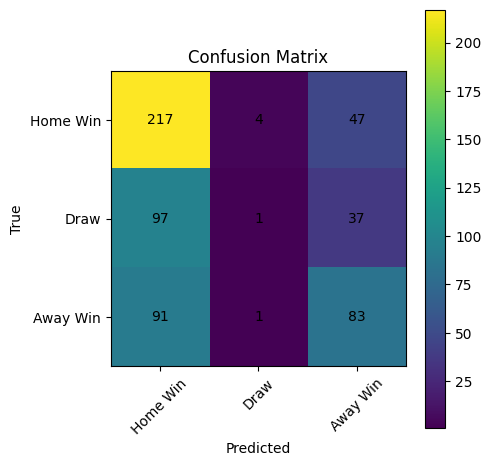

In [ ]:
labels = ["Home Win", "Draw", "Away Win"]

cm = confusion_matrix(y_test, preds_class)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(3), labels, rotation=45)
plt.yticks(range(3), labels)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


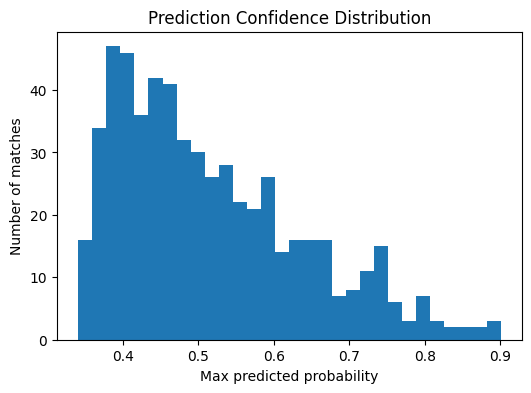

In [ ]:
#DISTRIBUCIÓN DE PROBABILIDADES (¿qué tan seguro es?)
probs = torch.softmax(preds, dim=1).cpu().numpy()

plt.figure(figsize=(6, 4))
plt.hist(probs.max(axis=1), bins=30)
plt.xlabel("Max predicted probability")
plt.ylabel("Number of matches")
plt.title("Prediction Confidence Distribution")
plt.show()


In [ ]:
#Mal predicho pero con alta confianza
results = test_df.copy()
results["pred"] = preds_class
results["confidence"] = probs.max(axis=1)
results["correct"] = results["pred"] == results["target"]

#errores con alta confianza
hard_errors = results[
    (results["correct"] == False) &
    (results["confidence"] > 0.6)
]

hard_errors[
    ["date", "target", "pred", "confidence"]
].head(10)


,date,target,pred,confidence
18724,2016-04-01,2,0,0.662180
18739,2016-04-02,1,0,0.669950
18745,2016-04-02,1,0,0.676416
18757,2016-04-02,1,0,0.609186
18761,2016-04-02,1,0,0.661452
18773,2016-04-03,1,0,0.660608
18783,2016-04-03,1,0,0.693927
18789,2016-04-03,2,0,0.656493
18807,2016-04-08,1,0,0.657209
18853,2016-04-09,0,2,0.604296


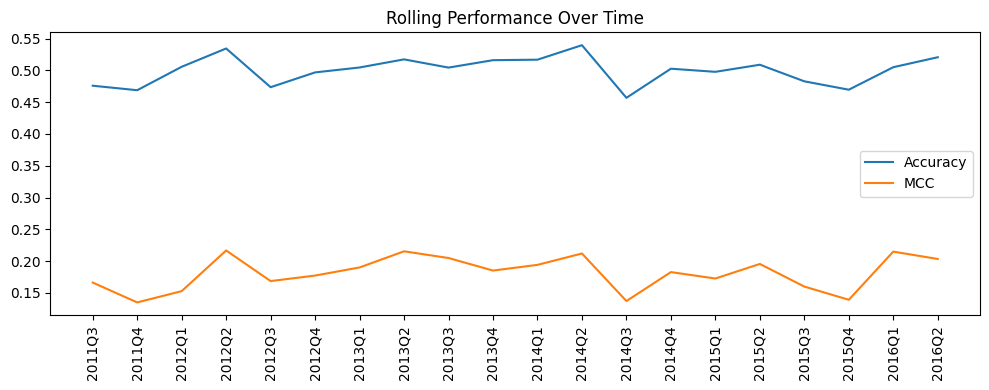

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(results_df["period"], results_df["acc"], label="Accuracy")
plt.plot(results_df["period"], results_df["mcc"], label="MCC")
plt.xticks(rotation=90)
plt.title("Rolling Performance Over Time")
plt.legend()
plt.tight_layout()
plt.show()
